# Introduction au Machine Learning

##### Importation des packages 

In [ ]:
import dataset as ds
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import collections
from sklearn.decomposition import PCA


##### On charge le dataset et on le découvre

In [39]:
digits = datasets.load_digits()
print(f"Colonnes du dataset :",digits.keys())
print(f"Targets :",digits.target_names)
print(f"Première images :\n",digits.images[0])
print(f"Nombre d'images :",digits.images.shape[0])

Colonnes du dataset : dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Targets : [0 1 2 3 4 5 6 7 8 9]
Première images :
 [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Nombre d'images : 1797


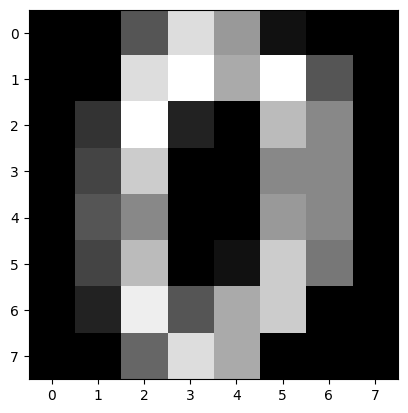

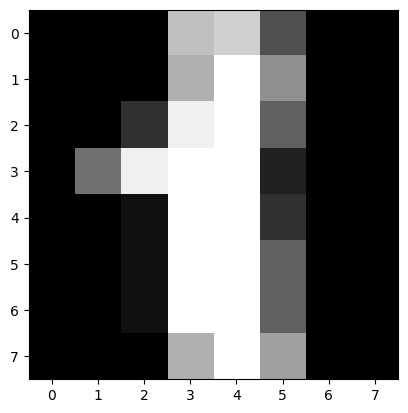

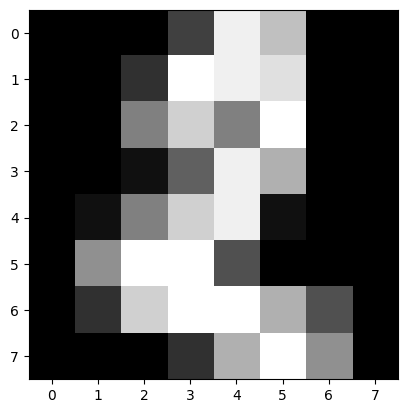

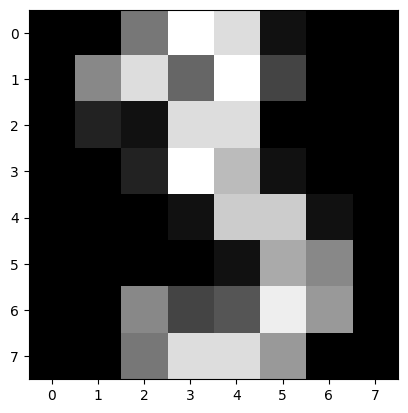

In [40]:
for i in range(4):
    plt.imshow(digits.images[i],cmap='gray')
    plt.show()

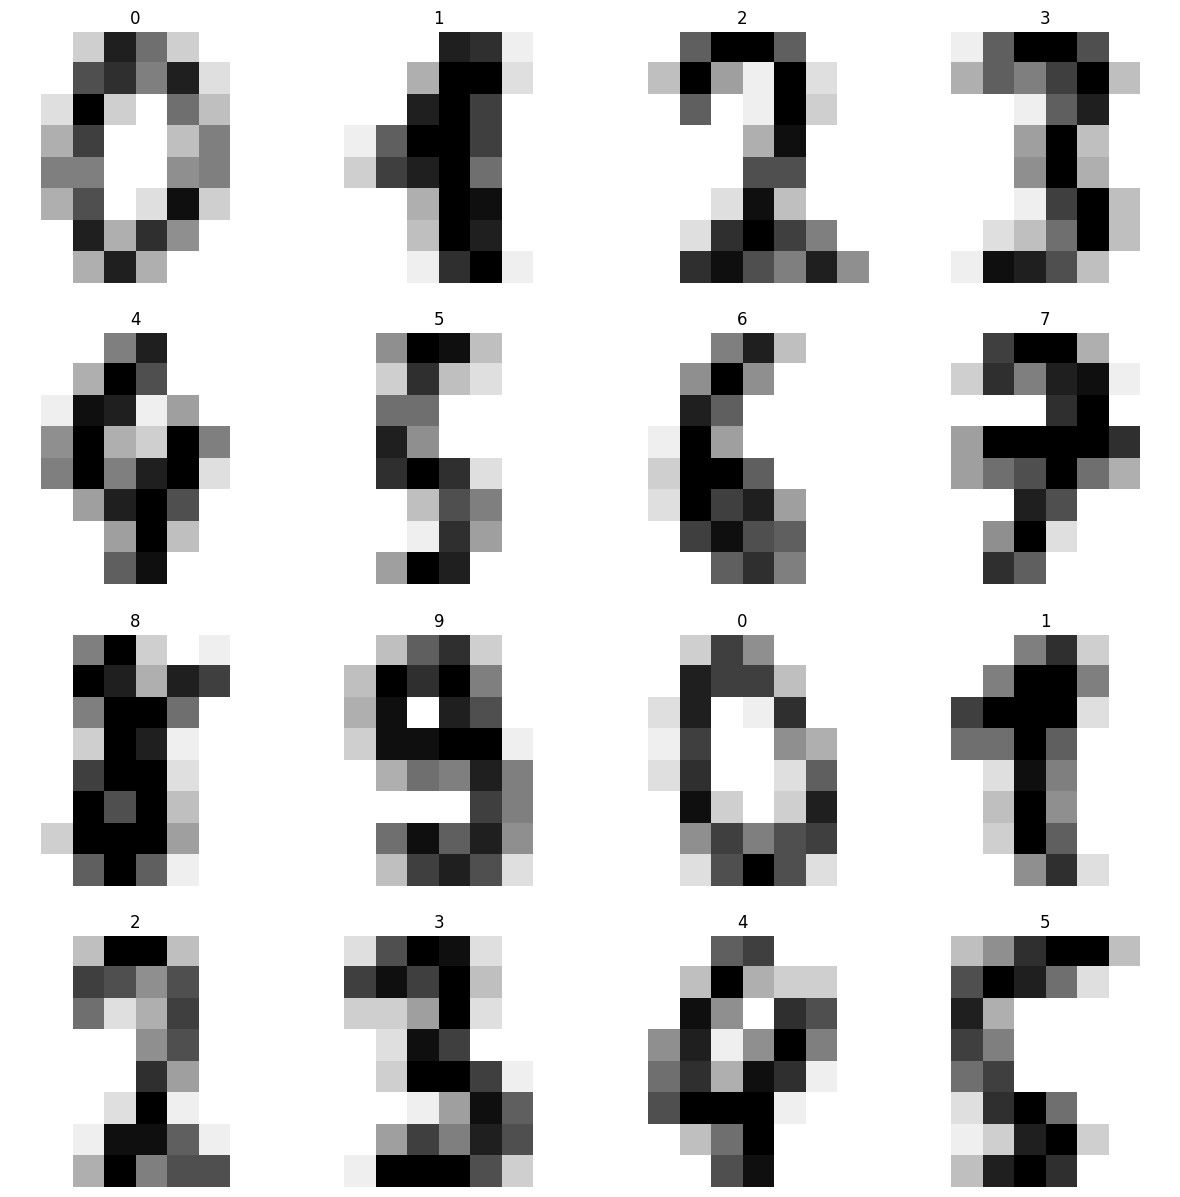

In [41]:
# Display at least one random sample par class (some repetitions of class... oh well)
def plot_multi(data, y):
    '''Plots 16 digits'''
    nplots = 16
    nb_classes = len(np.unique(y))
    cur_class = 0
    fig = plt.figure(figsize=(15,15))
    for j in range(nplots):
        plt.subplot(4,4,j+1)
        to_display_idx = np.random.choice(np.where(y == cur_class)[0])
        plt.imshow(data[to_display_idx].reshape((8,8)), cmap='binary')
        plt.title(cur_class)
        plt.axis('off')
        cur_class = (cur_class + 1) % nb_classes
    plt.show()


plot_multi(digits.data, digits.target)


In [42]:

# TODO: Create a feature matrix and a vector of labels
X = digits.data
y = digits.target_names

# Print dataset shape
print(f"Feature matrix shape: {X.shape}. Max value = {np.max(X)}, Min value = {np.min(X)}, Mean value = {np.mean(X)}")
print(f"Labels shape: {y.shape}")


Feature matrix shape: (1797, 64). Max value = 16.0, Min value = 0.0, Mean value = 4.884164579855314
Labels shape: (10,)


In [43]:
maxi = max(map(max,X))
F = X/maxi
# Print matrix shape
print(f"Feature matrix F shape: {F.shape}. Max value = {np.max(F)}, Min value = {np.min(F)}, Mean value = {np.mean(F)}")


Feature matrix F shape: (1797, 64). Max value = 1.0, Min value = 0.0, Mean value = 0.30526028624095713


In [ ]:

##########################################
## Dimensionality reduction
##########################################


### just an example to test, for various number of PCs
sample_index = 0
original_image = F[sample_index].reshape(8, 8)  # Reshape back to 8×8 for visualization
original_image.reshape(1,64)
original_image.reshape(8,8)
# TODO: Using the specific sample above, iterate the following:
# * Generate a PCA model with a certain value of principal components
# * Compute the approximation of the sample with this PCA model
# * Reconstruct a 64 dimensional vector from the reduced dimensional PCA space
# * Reshape the resulting approximation as an 8x8 matrix
# * Quantify the error in the approximation
# Finally: plot the original image and the 15 approximation on a 4x4 subfigure


array([[0.    , 0.    , 0.3125, 0.8125, 0.5625, 0.0625, 0.    , 0.    ,
        0.    , 0.    , 0.8125, 0.9375, 0.625 , 0.9375, 0.3125, 0.    ,
        0.    , 0.1875, 0.9375, 0.125 , 0.    , 0.6875, 0.5   , 0.    ,
        0.    , 0.25  , 0.75  , 0.    , 0.    , 0.5   , 0.5   , 0.    ,
        0.    , 0.3125, 0.5   , 0.    , 0.    , 0.5625, 0.5   , 0.    ,
        0.    , 0.25  , 0.6875, 0.    , 0.0625, 0.75  , 0.4375, 0.    ,
        0.    , 0.125 , 0.875 , 0.3125, 0.625 , 0.75  , 0.    , 0.    ,
        0.    , 0.    , 0.375 , 0.8125, 0.625 , 0.    , 0.    , 0.    ]])